# Lipid enrichment around proteins and fingerprints

...

This notebook relies on several modules, notably numpy and matplotlib, as well as the module `taw` that contains a class `TrajectoryWithPBC` for reading in coordinates from a trajectory with PBC using MDAnalysis, and defines several manners to deal with coordinates under periodicity. This seems to be complementary to what Freud offers. The first cell also contains a very simple class for timing different steps, that defines a context with a name, signifying what is being timed. 

In [1]:
import taw
import numpy as np
import os
print(os.environ.get('OMP_NUM_THREADS'))
os.environ['OMP_NUM_THREADS'] = '2'
print(os.environ.get('OMP_NUM_THREADS'))

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import tri
import glob

2,1
2


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Trajectories are read in in series here. The 100\*100 trajectories each have 3.5k frames, which seems overkill.

Todo:

* separating leaflets
* curvature

# Specific for PsbS

# 1) Low pH Monomer thylakoid membrane

In [2]:
# The operations are timed using a simple timer class.
#
# ±25s per trajectory with 3.3k frames of 16.4k beads (selecting non water)
# 6 seconds for centering and putting everything in box per trajectory
# ±17s for centering, making compact and aligning
# ±6 seconds for centering and aligning
# ±2 seconds for centering
# ±20 seconds for making compact
timing = taw.Timer()


# A series of trajectories is read using glob for finding them.
# For reading, a selection of atoms can be provided (selection)
# and the subset of frames can be specified (start, stop, step).
# For each trajectory and each frame, the protein is positioned
# at the origin and all atoms are positioned around it in 
# compact representation (compact).
with timing('Reading trajectories'):
    trjs = [
        taw.TrajectoryWithPBC(
            tpr=f'{i}/no_solvent.tpr', 
            trj=f'{i}/no_rot_trans.xtc', 
            selection='not resname W NA CL',
            step=1
        ).compact('protein')
        
        for i in ['/martini/rubiz/partner/pairs_local/psbs_4_0_monomer_rep1', '/martini/rubiz/partner/pairs_local/psbs_4_0_monomer_rep2', '/martini/rubiz/partner/pairs_local/psbs_4_0_monomer_rep3']
        #for i in ['301_psbs_dimer_1mol_rep1']

    ]
print("Number of trajectories: "+ str(len(trjs)))

# All frames are aligned in X/Y (in-plane fit) to a common reference
with timing('Aligning all frames to common reference in xy plane'):
    reference = trjs[0]['protein'][0].coords
    reference -= reference.mean(axis=0)
    trjs = [ trj.alignxy('protein', reference) for trj in trjs ]


print(timing)

Number of trajectories: 3
Reading trajectories: 34.790035s
Aligning all frames to common reference in xy plane: 4.778085s



Plot limits:(np.float64(-110.99121978685413), np.float64(110.4855469486796), np.float64(-104.79908067581624), np.float64(104.5761407454249))


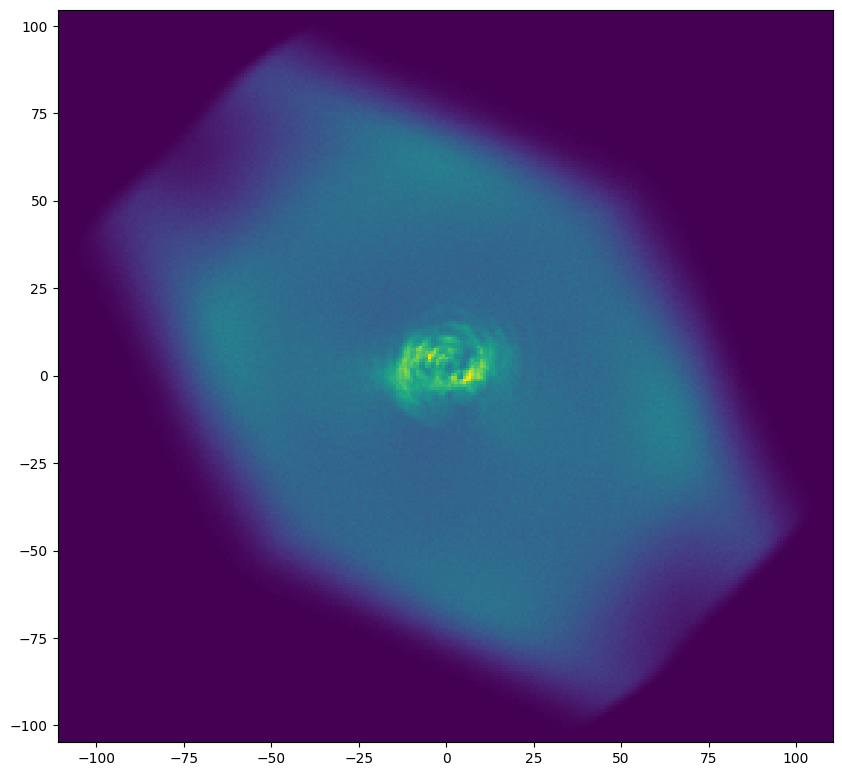

Density plot: 3.722003s



In [3]:
# Nice to have a view of the system and check the alignment
with timing('Density plot'):
    plt.subplots(figsize=(10, 10))
    plt.hist2d(*trjs[0][:, :, :2].reshape((-1, 2)).T, bins=266)
    #set limits
    #print data limits
    print('Plot limits:' + str(plt.axis()))
    plt.gca().set_aspect('equal')
    plt.show()

print(timing)

In [5]:
# From here not bothering with PBC anymore, 
# but will be using selections.

with timing('Selecting lipids'):
    membrane = [ trj['not protein and not resname ION NA CL'] for trj in trjs ]

with timing('Selecting protein'):
    protein = [ trj['protein'] for trj in trjs ]

print(timing)

Selecting lipids: 5.201092s
Selecting protein: 0.317374s



## Determining the membrane center

The membrane center is here determined for the whole cell. 

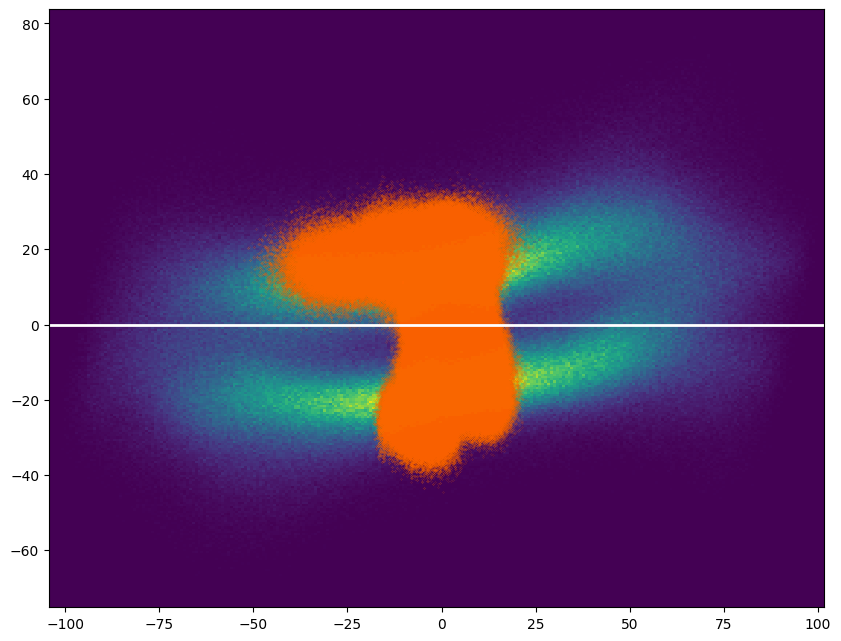

In [6]:
# This will iterate of the trajectories (which are stored in a list)
# and determine the center of the lipid z-coordinates, then 
# subtracting that center from both the lipid and protein trajectories.
for lip, prot in zip(membrane, protein):
    mid = lip.coords[:, :, 2].mean(axis=1)
    lip[:, :, 2] -= mid[:, None]
    prot[:, :, 2] -= mid[:, None]

        
# Plotting the PO4 beads and the protein, to show the centering
plt.subplots(figsize=(10, 10))
plt.hist2d(*membrane[0]['name GL1'].coords[:, :, 1:].reshape((-1, 2)).T, bins=266)
plt.scatter(*protein[0].coords[:, :, 1:].reshape((-1, 2)).T, s=0.01, c='#f60')
plt.axhline(0, linewidth=2, c='white')
plt.gca().set_aspect('equal')
plt.show()
    


In [7]:
# Here the membrane is split in individual lipid types,
# which are determined automatically from the atoms.
# The resulting per-lipid trajectories are stored in
# a dictionary.
# Define custom lipid groups
custom_lipid_groups = {
    'PG': ['YFPG', 'YPPG'],
    'MGDG': ['DFMG', 'FPMG'],
    'DGDG': ['DFGG', 'FPGG'],
    'SQDG': ['FPSQ']
}


In [8]:
#The following code will create a dictionary of lipid groups
lipids = {
    group: [t[f'resname {" ".join(species)}'] for t in membrane]
    for group, species in custom_lipid_groups.items()
}



In [9]:
def plot_protein():
    # Plotting the protein (separate chains)
    chains = protein[0]['name BB'].split('molecule')
    colors = ['black', 'darkgrey', 'grey', 'lightgrey']
    counter = 0
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c=colors[counter], linewidth=1, zorder=1)
        counter += 1

In [219]:
print(lipids.keys())


dict_keys(['PG', 'MGDG', 'DGDG', 'SQDG'])


/tmp/ipykernel_2485692/3765924713.py:45: RuntimeWarning: invalid value encountered in divide
  enrichment = (lipidA / matrix_all) * (n_lipids_all / n_lipidsA)


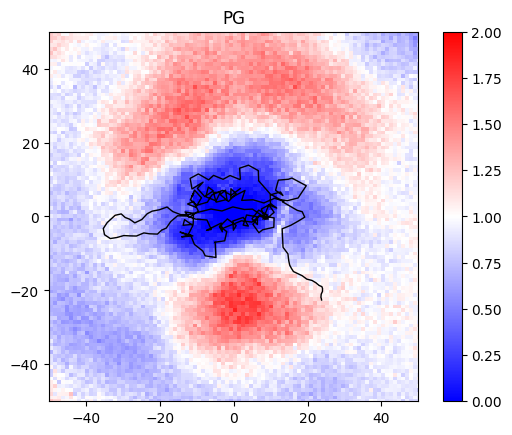

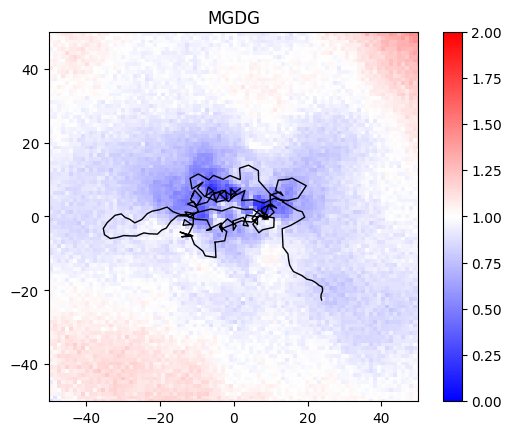

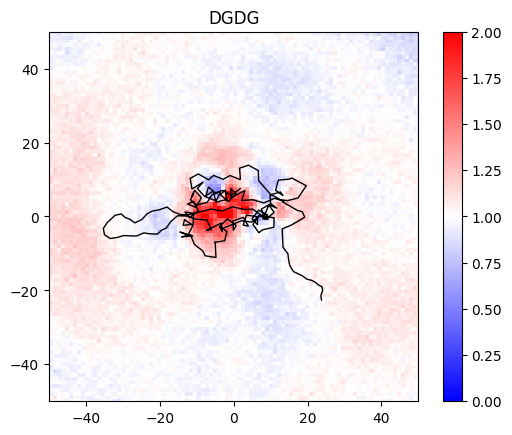

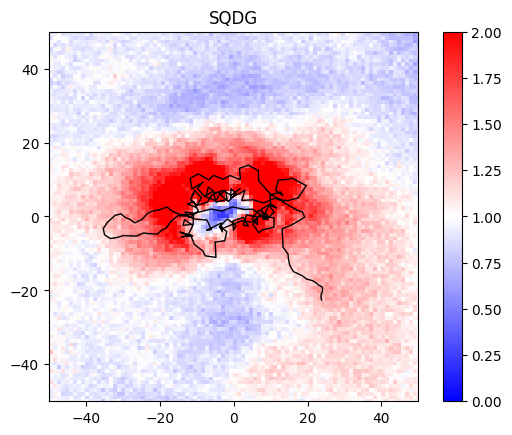

"\n#Plot the matrix in a new figure\nplt.figure()\nplt.imshow(matrix_all.T, extent=extent, origin='lower', cmap='bwr')\nplt.colorbar()\nn_lipids_all = matrix_all.sum()\n\n#Calculate the enrichment matrix\nenrichment_matrix = (lipidA / matrix_all) * (n_lipids_all / n_lipidsA)\n\n#Plot the enrichment matrix\nplt.figure()\nplt.imshow(enrichment_matrix.T, extent=extent, origin='lower', cmap='bwr', vmax=2, vmin=0)\nplot_protein()\nplt.xlim(-50, 50)\nplt.ylim(-50, 50)\nplt.colorbar()\nplt.show()\n"

In [14]:
"""

#Matrix with accumulated lipids
bins = [200, 200]
density_0 = lipco[1].coords[:, :, :2].reshape((-1, 2)).T
lipidA, xedges, yedges = np.histogram2d(density_0[0], density_0[1], bins=bins)

# Compute the extent from the bin edges: [xmin, xmax, ymin, ymax]
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

#plt.figure()
#plt.hist2d(density_0[0], density_0[1], bins=bins, cmap='bwr')
plt.figure()
# Note: transposing lipidA if needed, and setting origin to 'lower' to match hist2d output.
plt.imshow(lipidA.T, extent=extent, origin='lower', cmap='bwr')
plt.colorbar()
plt.show()

n_lipidsA = lipidA.sum()

#Sum the lipids from all the trajectories
matrix_all = np.zeros((bins[0], bins[1]))
for i in range(len(lipco)):
    density = lipco[i].coords[:, :, :2].reshape((-1, 2)).T
    lipid,  xedges, yedges = np.histogram2d(density[0], density[1], bins=bins)
    matrix_all += lipid
"""
bins = [200, 200]
#Sum the lipids from all the trajectories
matrix_list = []
lipid_names = []
for lip, lipco in lipids.items():
    density = lipco[0].coords[:, :, :2].reshape((-1, 2)).T
    lipid,  xedges, yedges = np.histogram2d(density[0], density[1], bins=bins)
    matrix_list.append(lipid)
    lipid_names.append(lip)

matrix_all = np.array(matrix_list).sum(axis=0)
n_lipids_all = matrix_all.sum()
#Calculate all enriched lipids
enrichment_all = []
for i in range(len(matrix_list)):
    lipidA = matrix_list[i]
    n_lipidsA = lipidA.sum()
    enrichment = (lipidA / matrix_all) * (n_lipids_all / n_lipidsA)
    enrichment_all.append(enrichment)

extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
#Plot the enrichment matrices
for i in range(len(enrichment_all)):
    plt.figure()
    plt.imshow(enrichment_all[i].T, extent=extent, origin='lower', cmap='bwr', vmax=2, vmin=0)
    plot_protein()
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)
    plt.colorbar()
    plt.title(lipid_names[i])
    plt.show()


"""
#Plot the matrix in a new figure
plt.figure()
plt.imshow(matrix_all.T, extent=extent, origin='lower', cmap='bwr')
plt.colorbar()
n_lipids_all = matrix_all.sum()

#Calculate the enrichment matrix
enrichment_matrix = (lipidA / matrix_all) * (n_lipids_all / n_lipidsA)

#Plot the enrichment matrix
plt.figure()
plt.imshow(enrichment_matrix.T, extent=extent, origin='lower', cmap='bwr', vmax=2, vmin=0)
plot_protein()
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.colorbar()
plt.show()
"""



## Hexagonal binning

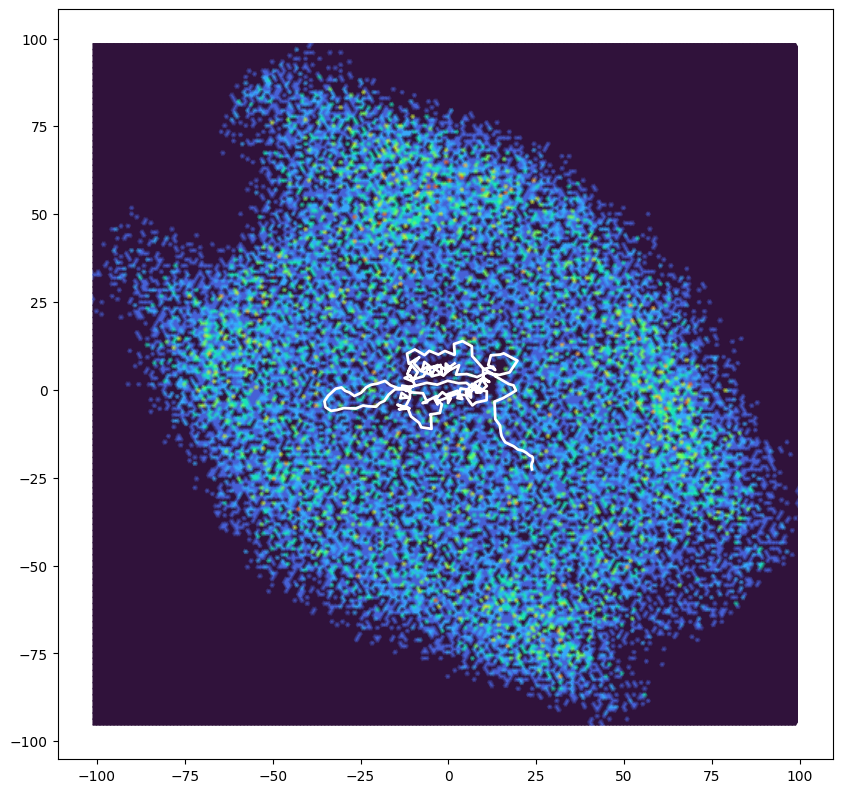

Hixelation: 1.336738s
Plotting: 0.411812s

In [11]:
with timing('Hixelation'):
    H = taw.HexagonalBins(np.array(membrane)[:, -1:], resolution=1)
    #H = taw.HexagonalBins(membrane[0], resolution=1)

with timing('Plotting'):
    plt.subplots(figsize=(10,10))
    # This plots the bins as a triangulated mesh, with
    # interpolated colors.
    # Binning is performed such that the vertex is the bin center
    plt.tripcolor(H.tri, H.counts, shading='gouraud', cmap='turbo')
    plt.gca().set_aspect('equal')
    
    # Plotting the protein (separate chains)
    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)

    plt.show()
    
timing

AttributeError: TriMesh.set() got an unexpected keyword argument 'weights'

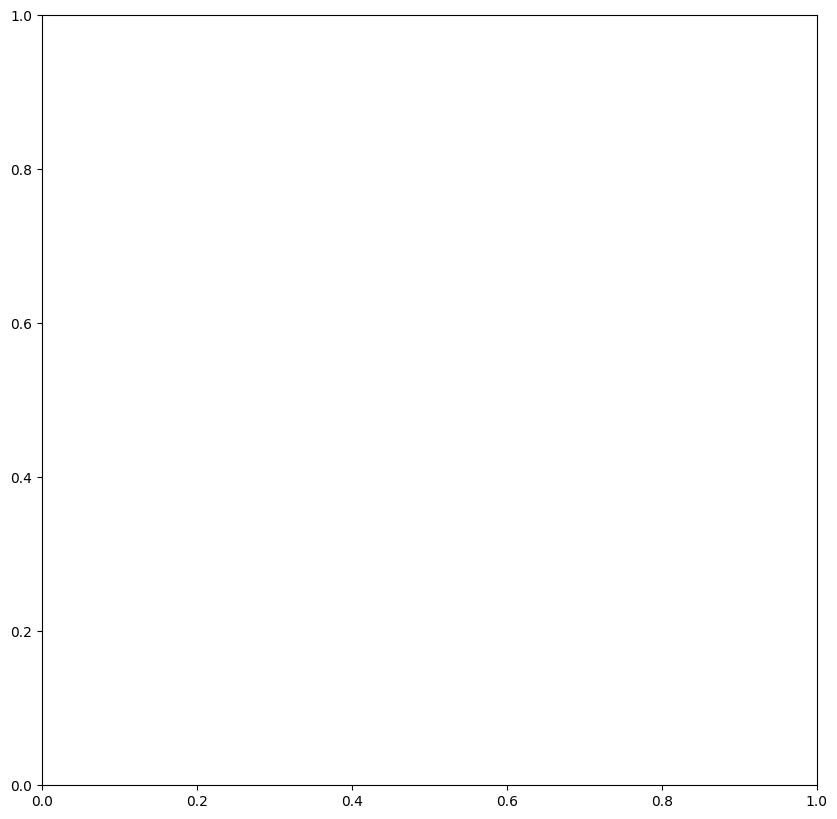

In [38]:




with timing('Hixelation'):
    #H = taw.HexagonalBins(np.array(membrane)[:, -100:], resolution=1)
    H = taw.HexagonalBins(membrane[0], resolution=1)

with timing('Plotting'):
    plt.subplots(figsize=(10,10))
    # This plots the bins as a triangulated mesh, with
    # interpolated colors.
    # Binning is performed such that the vertex is the bin center
    plt.tripcolor(H.tri, H.counts, shading='gouraud', cmap='turbo')
    plt.gca().set_aspect('equal')
    
    # Plotting the protein (separate chains)
    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    #Add a colorbar
    plt.colorbar()
    plt.show()
    
print(H.points.shape)
timing

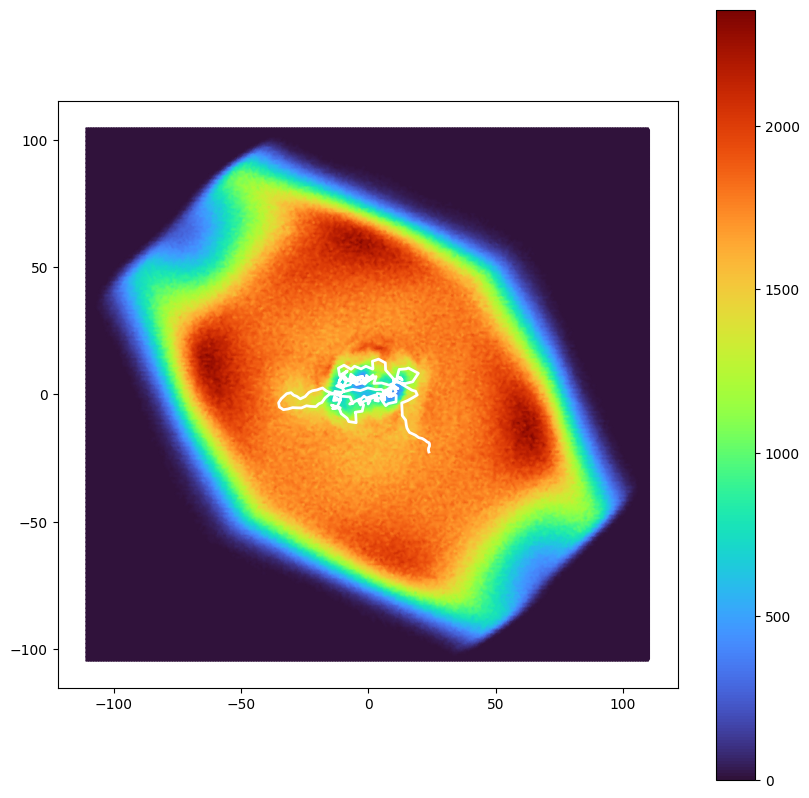

Plot limits:(np.float64(-50.0), np.float64(50.0), np.float64(-50.0), np.float64(50.0))


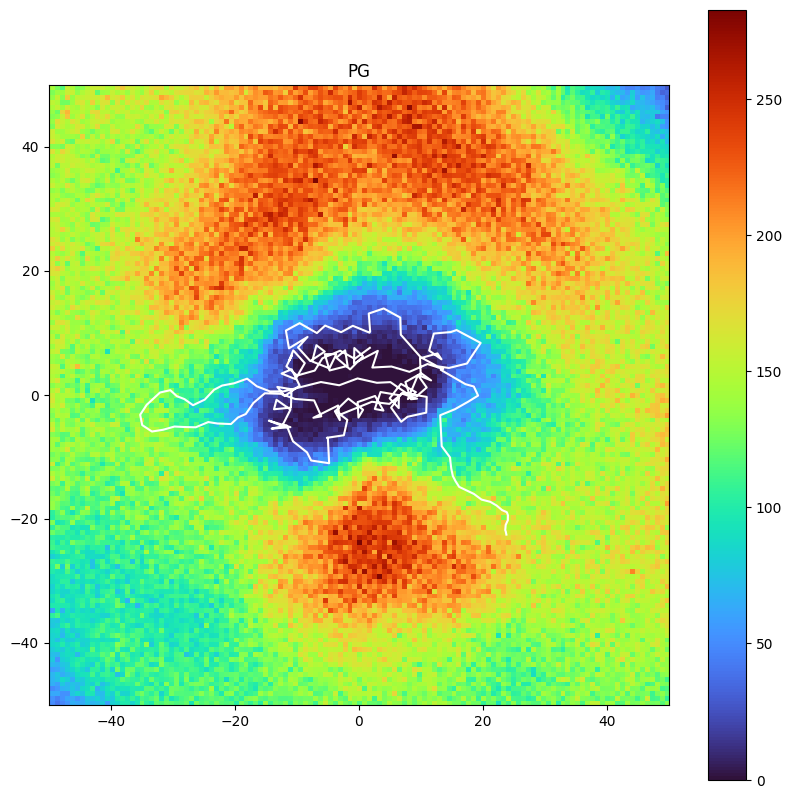

Plot limits:(np.float64(-50.0), np.float64(50.0), np.float64(-50.0), np.float64(50.0))


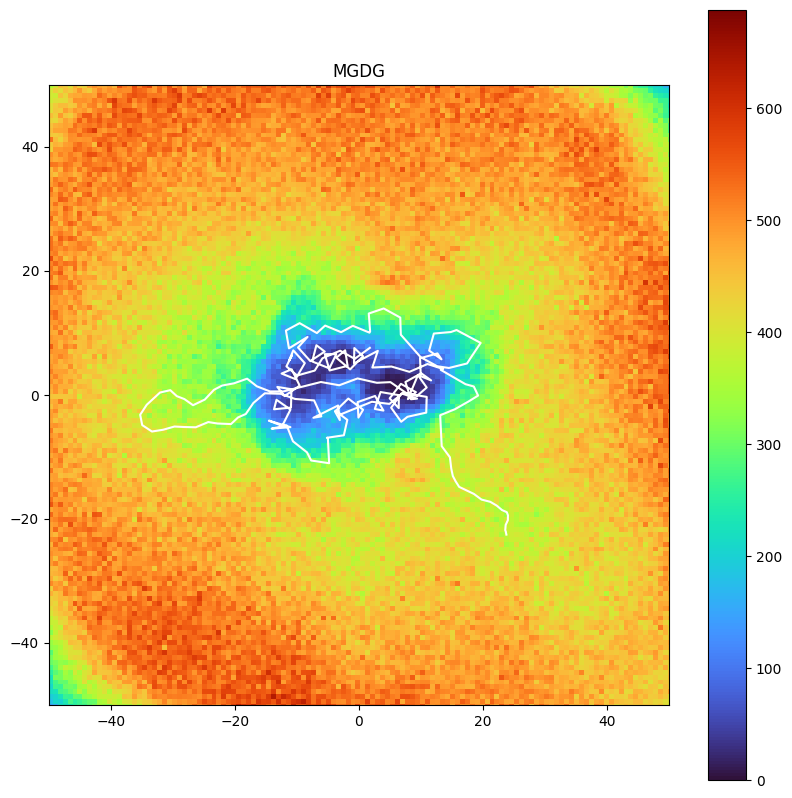

Plot limits:(np.float64(-50.0), np.float64(50.0), np.float64(-50.0), np.float64(50.0))


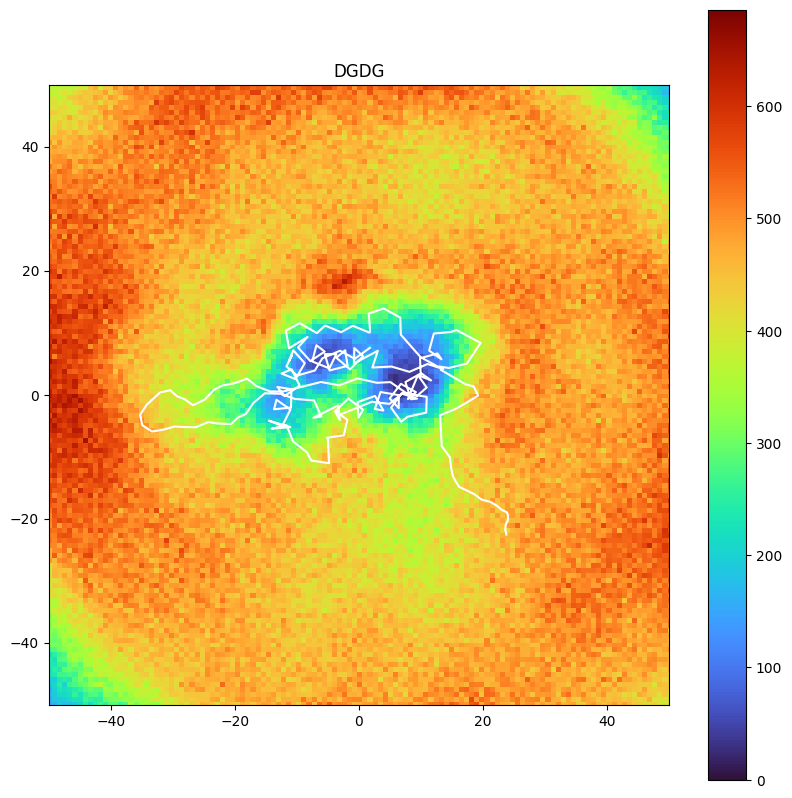

Plot limits:(np.float64(-50.0), np.float64(50.0), np.float64(-50.0), np.float64(50.0))


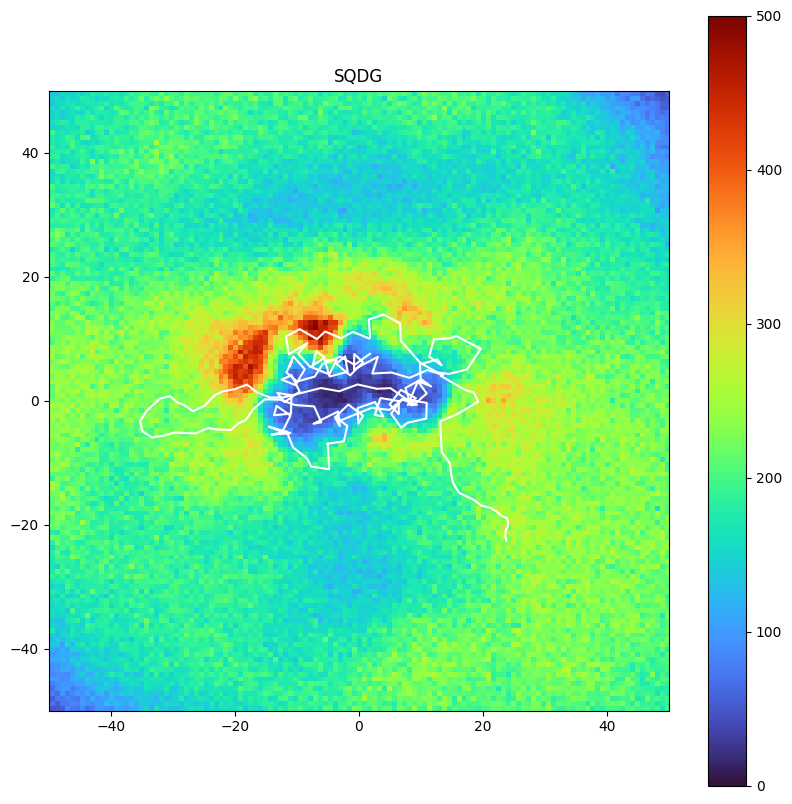

(3951, 9865, 3)


In [10]:
# Hexagonal binning
H = taw.HexagonalBins(membrane[0], resolution=1)

# Plotting hexagonal bins
plt.subplots(figsize=(10, 10))
plt.tripcolor(H.tri, H.counts, shading='gouraud', cmap='turbo')
plt.gca().set_aspect('equal')

# Plotting the protein (separate chains)
chains = protein[0]['name BB'].split('molecule')
for p in chains:
    p = p.coords[:, :, :2].mean(axis=0)
    plt.plot(*p.T, c='white', linewidth=2, zorder=1)

# Add a colorbar
plt.colorbar()
plt.show()

# Plotting 2D histogram for lipids
for lip, lipco in lipids.items():
    plt.subplots(figsize=(10, 10))
    plt.hist2d(
        *lipco[0].coords[:, :, :2].reshape((-1, 2)).T, 
        bins=[270, 260], cmap='turbo'
    )
    chains = protein[0]['name BB'].split('molecule')
    p = chains[0].coords[:, :, :2].mean(axis=0)
    plt.plot(*p.T, c='white', linewidth=1.5, zorder=1)
    plt.gca().set_aspect('equal')
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)
    plt.colorbar()
    plt.title(lip)
    print('Plot limits:' + str(plt.axis()))
    plt.show()

print(H.points.shape)

In [1]:
for lip, lipco in lipids.items():
    with timing(lip):
        plt.subplots(figsize=(10, 10))
        plt.hist2d(
            *lipco[0].coords[:, :, :2].reshape((-1, 2)).T, 
            bins=[270, 260], cmap='turbo'
        )
        chains = protein[0]['name BB'].split('molecule')
        p = chains[0].coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=1.5, zorder=1)
        plt.gca().set_aspect('equal')
        plt.xlim(-50, 50)
        plt.ylim(-50, 50)
        plt.colorbar()
        plt.title(lip)
        print('Plot limits:' + str(plt.axis()))
        plt.show()

NameError: name 'lipids' is not defined

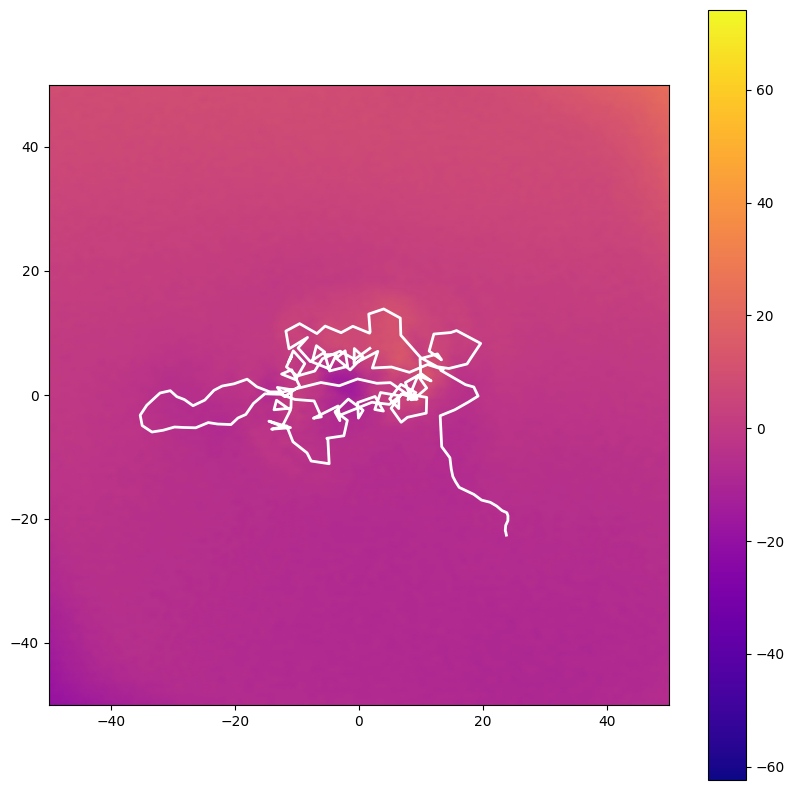

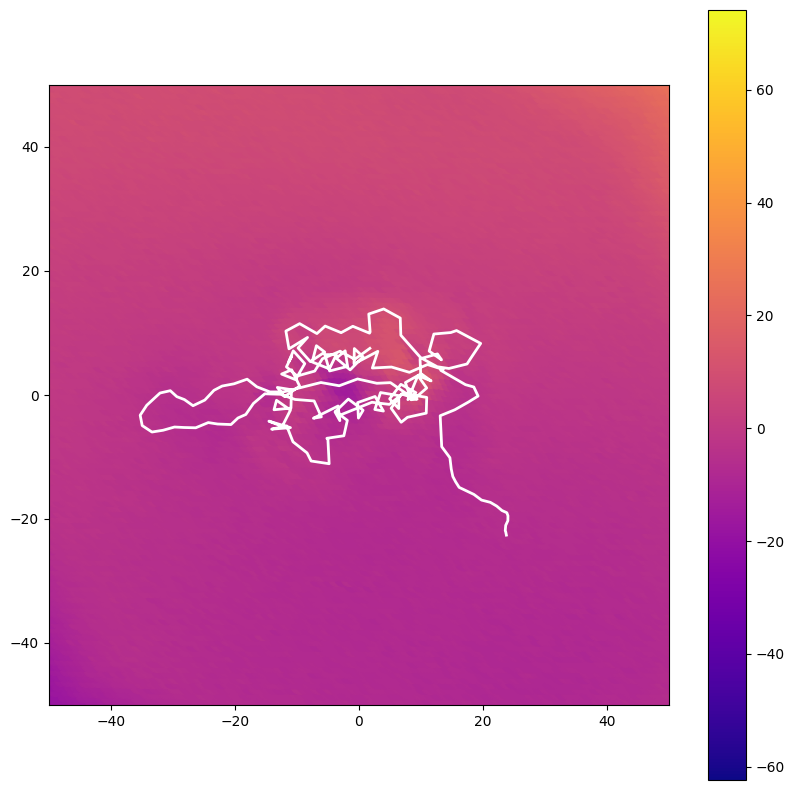

Some property (mean z coordinate): 1.705426s
Plotting: 0.359943s
Plotting: 0.382339s

In [17]:
with timing('Some property (mean z coordinate)'):
    zmean = H(lambda x: x[:, 2].mean())
    

with timing('Plotting'):
    plt.subplots(figsize=(10,10))
    p = chains[0].coords[:, :, :2].mean(axis=0)
    plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    plt.tripcolor(H.tri, zmean, shading='gouraud', cmap='plasma')
    plt.gca().set_aspect('equal')
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)
    plt.colorbar()

    # Plotting the protein (separate chains)
    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    plt.show()

with timing('Plotting'):
    plt.subplots(figsize=(10,10))
    p = chains[0].coords[:, :, :2].mean(axis=0)
    plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    plt.scatter(*H.grid.T, s=.1*H.counts, c=zmean, cmap='plasma')
    plt.gca().set_aspect('equal')
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)
    plt.colorbar()

    # Plotting the protein (separate chains)
    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    plt.show()

timing

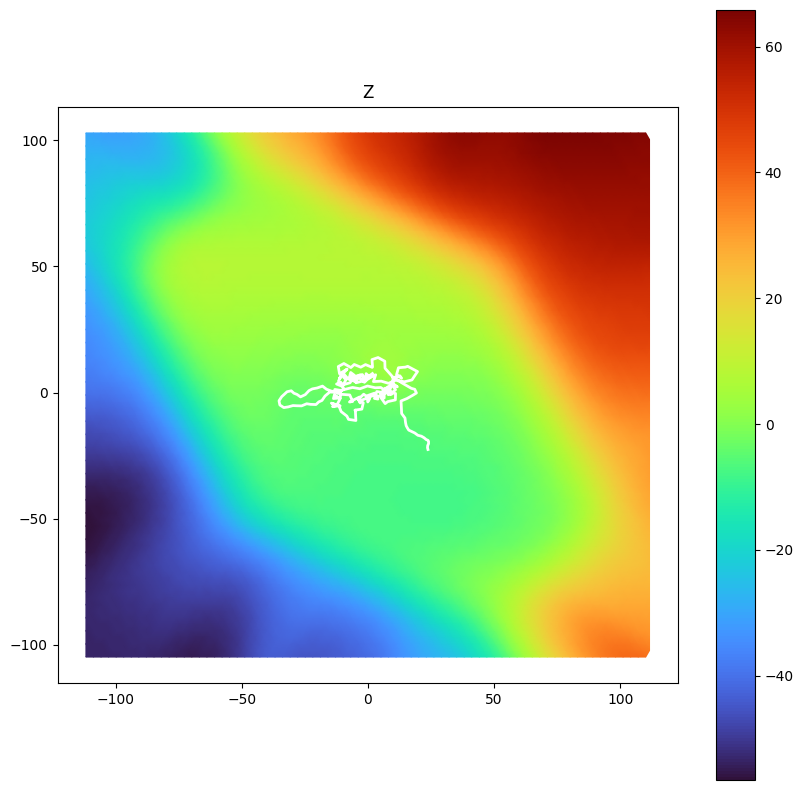

KDE: 4.986877s
Plotting: 0.175491s

In [18]:
with timing('KDE'):
    # Doing KDE's for z-positions and residue type counts
    G, w, F, FN = H.kde(features=zmean[:, None], resolution=3, chunksize=1e5, sd=100)

with timing('Plotting'):
    T = taw.tri.Triangulation(G[:, 0], G[:, 1])

    fig, ax = plt.subplots(figsize=(10, 10))
    plt.tripcolor(T, F[:, 0], shading='gouraud', cmap='turbo')
    plt.colorbar()
    plt.title('Z')

    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)

    plt.gca().set_aspect('equal')
    plt.show()

timing

In [114]:
#print size H
print(len(H.points[0]))
print(H.points.shape)

1
(1, 1, 9660, 3)


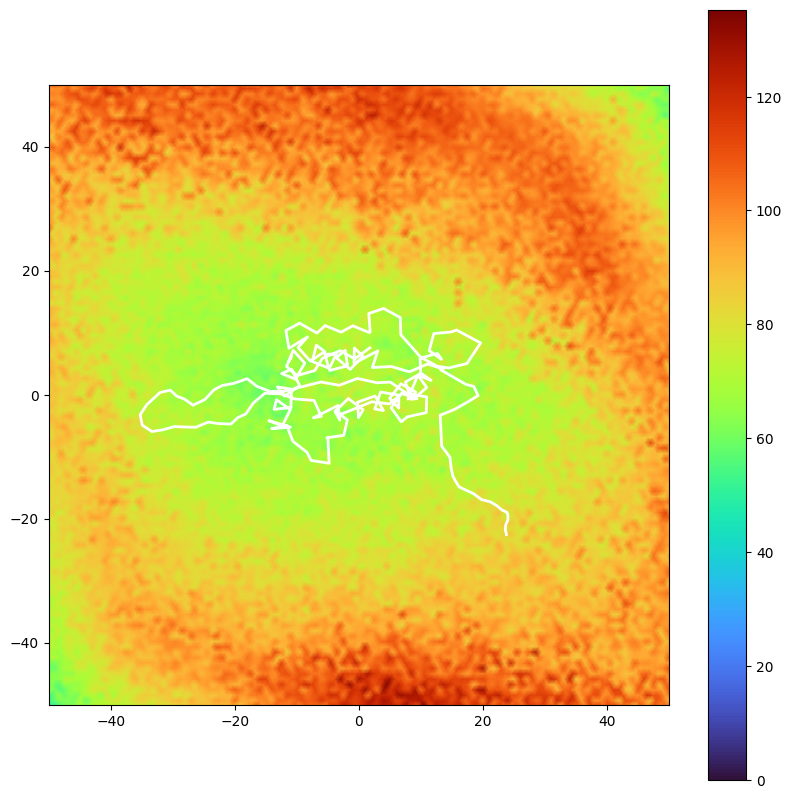

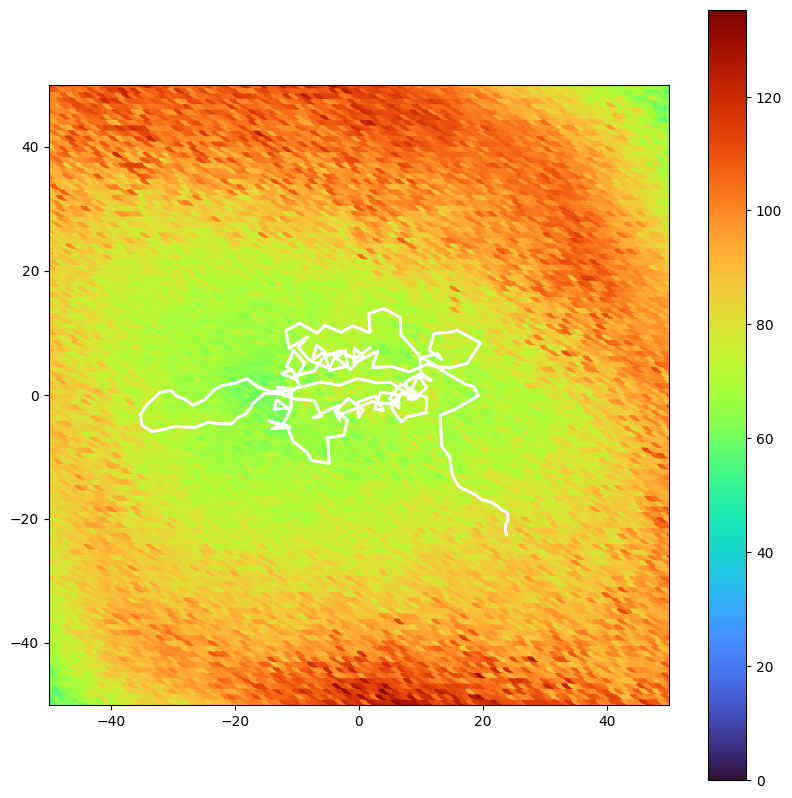

Some property (mean z coordinate): 1.634964s
Plotting: 0.469392s
Plotting: 0.358716s

In [27]:
with timing('Some property (mean z coordinate)'):
    z_thickness_ang = H(lambda x: x[:, 2].max() - x[:, 2].min())
    
#Convert to nm
#z_thickness = z_thickness_ang/10

with timing('Plotting'):
    plt.subplots(figsize=(10,10))
    plt.tripcolor(H.tri, z_thickness_ang, shading='gouraud', cmap='turbo')
    plt.gca().set_aspect('equal')
    plt.colorbar()
    #Set limits
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)
    #Set higher dpi 
     # Plotting the protein (separate chains)
    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    plt.show()

with timing('Plotting'):
    plt.subplots(figsize=(10,10))
    plt.scatter(*H.grid.T, s=.1*H.counts, c=z_thickness_ang, cmap='turbo')

    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    plt.gca().set_aspect('equal')
     # Plotting the protein (separate chains)
    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)
    plt.colorbar()
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)


    plt.show()

timing

In [19]:
with timing('KDE'):
    # Doing KDE's for z-positions and residue type counts
    G, w, F, FN = H.kde(features=z_thickness[:, None], resolution=3, chunksize=1e5, sd=100)

with timing('Plotting'):
    T = taw.tri.Triangulation(G[:, 0], G[:, 1])

    fig, ax = plt.subplots(figsize=(20, 20))
    plt.tripcolor(T, F[:, 0], shading='gouraud', cmap='turbo')
    plt.colorbar()
    plt.title('Z')

    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)

    plt.gca().set_aspect('equal')
    plt.show()

timing

NameError: name 'z_thickness' is not defined

---

Here be dragons...


## Distributions per leaflet and flip-flops

In [ ]:
lname = 'PAPI'

with timing(f'{lname} flip-flops'):
    # nlip, nframes, natoms, ndim
    lip = np.array([ x for lip in lipids[lname] for x in lip.split('residue') ])
    mlip = lip.mean(axis=2)

    fig, ax = plt.subplots(figsize=(10, 5))
    rng = np.arange(len(mlip[0]))
    flop = 0
    for ilip in lip:
        pos = ilip[:, :, 2].mean(axis=1) > 0
        #print(pos.sum() / len(pos))
        if pos.sum() and (~pos).sum():
            flop += 1
            plt.plot(rng, ilip[:, :, 2], c='red', linewidth=0.1, zorder=1)
        else:
            plt.plot(rng, ilip[:, :, 2], c='grey', linewidth=1, zorder=0)
    plt.show()
    
timing

In [ ]:
resolution = 10
dotsize = 320
figsize = (10, 10)

# This takes virtually no time
# Only one grid is used for all trajectories and all frames, to allow combining the results
# This should be fine, since all were setup with the same PBC
G = taw.PBCHexagonalGrid(trjs[0].pbc, resolution=resolution)

with timing('Densities'):
    densities = {
        lip: [ G.kde(B[f'resname {lip}'], bw=200) for B in trjs ]
        for lip in lipids
    }

timing

In [ ]:
fig, ax = plt.subplots(figsize=figsize)
plt.scatter(*G.points.T, s=dotsize, c=CDL1[0][-100:].mean(axis=0))

# This is for visualization
# The points are transformed to the average PBC from the grid
P = trjs[0]['protein'].bcoords[:, :, :2].reshape((-1, 2)).coords @ G.avg
plt.scatter(*P.T, s=.001, c='#ffcc0022')

# Coordinates should always be shown with equal aspect ratio
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=figsize)
plt.scatter(*G.points.T, s=dotsize, c=CDL1[1][-100:].mean(axis=0))

# This is for visualization
# The points are transformed to the average PBC from the grid
P = trjs[1]['protein'].bcoords[:, :, :2].reshape((-1, 2)).coords @ G.avg
plt.scatter(*P.T, s=.00025, c='#ffffff22')

# Coordinates should always be shown with equal aspect ratio
plt.gca().set_aspect('equal')
plt.show()

## Hexagonal grid and property KDEs

In [ ]:
def hexgrid(points, resolution=1.0, padding=0.1):
    # Bounding box, taking into account padding and the shifting of rows
    mnx, mny = points.min(axis=0) - padding - (0.25 * resolution, 0)
    mxx, mxy = points.max(axis=0) + padding + (0.25 * resolution, 0)
    # This gives a hexagonal grid in a very simple way
    G = np.mgrid[mnx:mxx:resolution, mny:mxy:resolution*0.75**0.5]
    # Shift the odd rows
    G[0, :, 1::2] += 0.5*resolution
    # Reshape to an array of 2D points
    G = G.T.reshape((-1, 2))
    return G


def gaussian(A, sd=100):
    return np.exp(-A / sd)

    
def kde(grid, points, features=None, chunksize=1e7, chunkgrid=False, kernel=gaussian, **kwargs):
    '''Estimate kernel density of points on grid positions'''
    
    # The features should be an array with the same first dimension as the points
    # I.e., there's a value for each point
    if features is not None:
        features = features.reshape((len(features), -1)).T
        featmask = features.astype(bool)
        featweight = np.zeros((len(features), len(grid)))
        featnorm = np.zeros_like(featweight)
    
    if chunkgrid:
        # Determine how many rows to read in a batch so as
        # not to exceed the maximum chunk size
        chunk = max(1, int(chunksize / len(points)))

        weights = np.zeros(len(grid))
        for i in range(0, len(grid), chunk):
            slc = slice(i, i+chunk)
            P = grid[slc]
            # The weight of each point (selected) at each grid point
            W = kernel(((P[:, None] - points[None, :])**2).sum(axis=2))
            weights[slc] = W.sum(axis=1)
            if features is None:
                continue
            for fid, feat in enumerate(features):
                fm = featmask[fid]
                FW = W[:, fm]
                featnorm[fid, slc] = FW.sum(axis=1)
                featweight[fid, slc] += (FW * feat[fm]).sum(axis=1)
    else:
        # Determine how many rows to read in a batch so as
        # not to exceed the maximum chunk size
        chunk = max(1, int(chunksize / len(grid)))

        weights = np.zeros(len(grid))
        for i in range(0, len(points), chunk):
            slc = slice(i, i+chunk)
            P = points[slc]
            # The weight of each point (selected) at each grid point
            W = kernel(((grid[:, None] - P[None, :])**2).sum(axis=2))
            weights += W.sum(axis=1)
            if features is None:
                continue
            for fid, feat in enumerate(features[:, slc]):
                fm = featmask[fid, slc]
                FW = W[:, fm]
                featnorm[fid] += FW.sum(axis=1)
                featweight[fid] += (FW * feat[fm]).sum(axis=1)

    if features is None:
        return weights, None, None

    featnorm[featnorm == 0.0] = 1
    return weights, (featweight / featnorm).T, featnorm.T


def kde2(grid, points, features=None, chunksize=1e7, kernel=gaussian, **kwargs):
    '''Estimate kernel density of points on grid positions'''
    # This version takes (at least) twice as long as the one above
    # This is because the chunk size is less wel controlled going
    # over (very very many) points and burdens the memory to swapping.
    # Reason to do it is that this approach allows deriving 
    # statistics per grid point, since all weights are determined
    # simultaneously.
            
    # The features should be an array with the same first dimension as the points
    # I.e., there's a value for each point
    if features is not None:
        features = features.reshape((len(features), -1)).T
        featmask = features.astype(bool)
        featweight = np.zeros((len(features), len(grid)))
        featnorm = np.zeros_like(featweight)
        
    # Determine how many rows to read in a batch so as
    # not to exceed the maximum chunk size
    chunk = max(1, int(chunksize / len(points)))

    weights = np.zeros(len(grid))
    for i in range(0, len(grid), chunk):
        slc = slice(i, i+chunk)
        P = grid[slc]
        # The weight of each point (selected) at each grid point
        W = kernel(((P[:, None] - points[None, :])**2).sum(axis=2))
        weights[slc] = W.sum(axis=1)
        if features is None:
            continue
        for fid, feat in enumerate(features):
            fm = featmask[fid]
            FW = W[:, fm]
            featnorm[fid, slc] = FW.sum(axis=1)
            featweight[fid, slc] += (FW * feat[fm]).sum(axis=1)

    if features is None:
        return weights, None, None

    featnorm[featnorm == 0.0] = 1
    return weights, (featweight / featnorm).T, featnorm.T

In [ ]:
with timing('Grid'):
    # Lipid coordinates and grid points
    L = membrane[0].coords.reshape((-1, 3))
    G = hexgrid(L[:, :2], resolution=10)

## Features to determine KDEs for

# Residue-type specific masks
resnames = membrane[0].universe.atoms.resnames
lipnames = set(resnames)
nframes = len(L) // len(resnames)

features = {
    lip:
    np.repeat(resnames == lip, nframes).reshape((len(resnames), -1)).T.flatten().astype(float)
    for lip in lipnames 
}
features['Z'] = L[:, 2]
features = pd.DataFrame(features)
    
with timing('KDE'):
    # Doing KDE's for z-positions and residue type counts
    w, F, FN = kde(G, L[:, :2], features.values, chunkgrid=True, sd=200, chunksize=1e5)

# For the counts, the normalisation (sum) is the actual feature
F[:, :-1] = FN[:, :-1]

timing
# resolution  time  quality
#     5       500   perfect
#    10       120   good
#    25        21   okay_for_testing
#    50         8   bad

In [ ]:
T = tri.Triangulation(G[:, 0], G[:, 1])

fig, ax = plt.subplots(figsize=(10, 10))
plt.tripcolor(T, w, shading='gouraud', cmap='turbo')
plt.colorbar()
plt.title('Atom count')

chains = protein[0]['name BB'].split('molecule')
for p in chains:
    p = p.coords[:, :, :2].mean(axis=0)
    plt.plot(*p.T, c='white', linewidth=2, zorder=1)

plt.gca().set_aspect('equal')
plt.show()

In [ ]:
for fi, label in zip(F.T, features.columns):
        
    fig, ax = plt.subplots(figsize=(10, 10))
    ok = np.isfinite(fi)
    plt.tripcolor(T, fi, shading='gouraud', cmap='turbo')
    plt.colorbar()
    plt.title(label)
    
    chains = protein[0]['name BB'].split('molecule')
    for p in chains:
        p = p.coords[:, :, :2].mean(axis=0)
        plt.plot(*p.T, c='white', linewidth=2, zorder=1)

    plt.gca().set_aspect('equal')
    plt.show()

---

    nx = 4
    ny = 8

    A:

      29 30 31 32   |                    | 26 27 28
    25 26 27 28     | 29 30 31           |           21 22 23
      21 22 23 24   |           26 27 28 | 18 19 20
    17 18 19 20     | 21 22 23           |           13 14 15
      13 14 15 16   |           18 19 20 | 10 11 12
     9 10 11 12     | 13 14 15           |            5  6  7
       5  6  7  8   |           10 11 12 |  2  3  4
     1  2  3  4     |  5  6  7           | 

                         (1)       (2)        (3)       (4)
                      
    1: A[:-1, 0::2]  A[1:, 0::2]  A[:-1, 1:-1:2] *
    2: A[:-1, 1::2]  A[1:, 1::2]  A[1:, 2:-1:2]
    3: A[:-1, 1::2]  A[1:, 1::2]  A[1:, 0:-1:2]  *
    4: A[:-1, 2::2], A[1:, 2::2]  A[:-1, 1:-1:2]

In [ ]:
# This is the exact/direct triangulation of the hexagonal grid
# which requires some bookkeeping 
with timing('Direct triangulation'):
    ny = len(np.unique(G[:, 1]))
    A = np.arange(len(G)).reshape((ny, -1)).T

    x = [ slice(None, -1), slice(1, None) ]
    s = [ slice(i, j, 2) for j in (None, -1) for i in (0, 1, 2) ]
    t = [ 
        (0, 0), (0, 1), (0, 1), (0, 2),
        (1, 0), (1, 1), (1, 1), (1, 2),
        (0, 1), (1, 5), (1, 3), (0, 4)
    ]

    t = [
        (0,0), (0,4), (0,1), (0,2), 
        (1,0), (1, 4), (1,1), (1,2), 
        (0,1), (1,2), (1,3), (0,4)
    ]

    T = np.concatenate([ 
        A[x[i], s[j]].flatten() for i, j in t 
    ]).reshape((3, -1)).T

    T = tri.Triangulation(G[:, 0], G[:, 1], T)

# The Delauney triangulation achieves the same in a single line
# (Well, under the hood it will be more lines than the above...)
# (The direct triangulation is much faster, but it's milliseconds anyway)
with timing('Delauney triangulation'):
    T = tri.Triangulation(G[:, 0], G[:, 1])
    
timing